# Model Diagnostics

### Imports 

In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

from life_expectancy.analysis.diagnostics import (
    group_error_table,
    plot_predicted_vs_actual,
    plot_residual_hist,
    plot_residuals_vs_predicted,
    time_slice_error_table,
    worst_errors_table,
)
from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.features.feature_engineering import prepare_numeric_model_frame
from life_expectancy.features.feature_selection import build_feature_sets_abc
from life_expectancy.modeling.experiments.core import run_time_experiment
from life_expectancy.modeling.model.baselines import ridge_cv
from life_expectancy.modeling.splits import filter_countries_min_years

### Verifying Project Root

In [33]:
from life_expectancy.data.utils import resolve_project_path


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = config.get("random_seed", 42)
TARGET = config["features"].get("target_col", "life_expectancy")
YEAR_COL = config["features"].get("year_col", "year")

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED)
print("Target:", TARGET)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Processed dir: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed
Target: life_expectancy


### Recreating Logic from Notebook 06

In [34]:
panel, preprocessing_summary = build_processed_dataset(config)

panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="raise").astype(int)

panel.head(), panel.shape

(       country  year      status  life_expectancy_who  adult_mortality  \
 0  Afghanistan  2015  Developing                 65.0            263.0   
 1  Afghanistan  2014  Developing                 59.9            271.0   
 2  Afghanistan  2013  Developing                 59.9            268.0   
 3  Afghanistan  2012  Developing                 59.5            272.0   
 4  Afghanistan  2011  Developing                 59.2            275.0   
 
    infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
 0             62     0.01               71.279624         65.0      100  ...   
 1             64     0.01               73.523582         62.0      100  ...   
 2             66     0.01               73.219243         64.0      100  ...   
 3             69     0.01               78.184215         67.0      100  ...   
 4             71     0.01                7.097109         68.0      100  ...   
 
            co2  health_expenditure_percent  education_expen

### Feature Set

In [35]:
model_df = prepare_numeric_model_frame(panel, config)
_, feature_sets, feature_meta = build_feature_sets_abc(panel, config)

FEATURES = feature_sets["B"]

print("Model frame:", model_df.shape)
print("Feature count:", len(FEATURES))
FEATURES

Model frame: (2265, 40)
Feature count: 31


['year',
 'adult_mortality',
 'infant_deaths',
 'alcohol',
 'percentage_expenditure',
 'hepatitis_b',
 'measles',
 'bmi',
 'polio',
 'total_expenditure',
 'diphtheria',
 'hiv_aids',
 'population',
 'thinness_1_19_years',
 'income_composition_of_resources',
 'schooling',
 'undernourishment',
 'co2',
 'health_expenditure_percent',
 'education_expenditure_percent',
 'unemployment',
 'corruption',
 'sanitation',
 'injuries',
 'status_flag',
 'gdp_log1p',
 'population_log1p',
 'co2_log1p',
 'gdp_missing_flag',
 'schooling_missing_flag',
 'sanitation_missing_flag']

## Time split + fit RidgeCV + prediction df with IDs

In [36]:
balanced_panel = filter_countries_min_years(
    panel,
    country_col="country",
    year_col=YEAR_COL,
    min_years=5,
)

model_df_time = prepare_numeric_model_frame(balanced_panel, config)
available_features = [col for col in FEATURES if col in model_df_time.columns]

print("Balanced panel:", balanced_panel.shape)
print("Time model frame:", model_df_time.shape)
print("Available features:", len(available_features))

Balanced panel: (2265, 37)
Time model frame: (2265, 40)
Available features: 31


In [37]:
row, pred_df, split_info, pipeline = run_time_experiment(
    df=model_df_time,
    feature_list=available_features,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="RidgeCV",
    model=ridge_cv(),
    scale_numeric="standard",
    test_years=3,
    split_label="time_reduced",
    id_cols=[YEAR_COL],
)

row

{'model_name': 'RidgeCV',
 'split_name': 'time_reduced',
 'n_train': 1812,
 'n_test': 453,
 'rmse': 3.1328904704928195,
 'mae': 2.492660883074589,
 'r2': 0.8599455879738946}

In [38]:
test_years = sorted(pred_df[YEAR_COL].unique())

metadata_cols = [
    col
    for col in ["country", "region", "income_group", YEAR_COL]
    if col in balanced_panel.columns
]

metadata = (
    balanced_panel[balanced_panel[YEAR_COL].isin(test_years)]
    .sort_values(["country", YEAR_COL])
    [metadata_cols]
    .reset_index(drop=True)
)

pred_df = pred_df.reset_index(drop=True)

for col in metadata_cols:
    if col not in pred_df.columns:
        pred_df[col] = metadata[col]

pred_df.head()

,y_true,y_pred,error,abs_error,year,country,region,income_group
0,64.1885,60.938839,-3.249661,3.249661,2015,Afghanistan,South Asia,Low income
1,61.4330,61.977513,0.544513,0.544513,2014,Afghanistan,South Asia,Low income
2,61.2125,61.517414,0.304914,0.304914,2013,Afghanistan,South Asia,Low income
3,77.9125,74.979675,-2.932825,2.932825,2015,Albania,Europe & Central Asia,Upper middle income
4,77.6565,75.640647,-2.015853,2.015853,2014,Albania,Europe & Central Asia,Upper middle income


### Predicted vs Actual

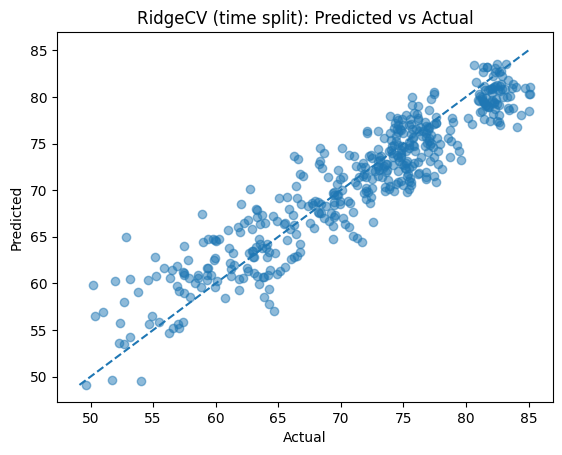

In [39]:
ax = plot_predicted_vs_actual(
    pred_df["y_true"],
    pred_df["y_pred"],
    title="RidgeCV (time split): Predicted vs Actual",
)

plt.show()

### Residuals vs Predicted

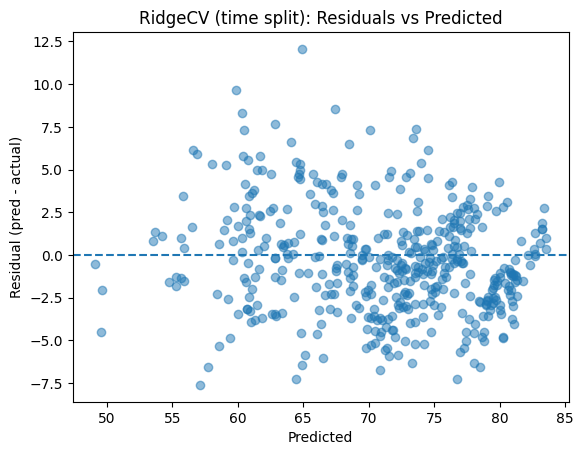

In [40]:
ax = plot_residuals_vs_predicted(
    pred_df["y_true"],
    pred_df["y_pred"],
    title="RidgeCV (time split): Residuals vs Predicted",
)

plt.show()

### Residual Histogram

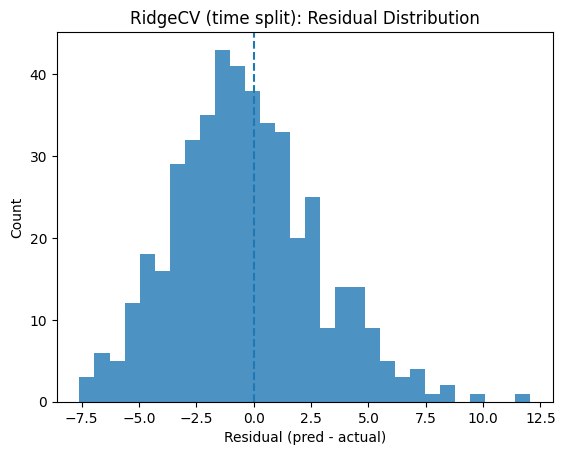

In [41]:
ax = plot_residual_hist(
    pred_df["y_true"],
    pred_df["y_pred"],
    title="RidgeCV (time split): Residual Distribution",
)

plt.show()

### Table: Worst Errors

In [42]:
worst_errors_table(pred_df, n=10)

,country,year,region,income_group,y_true,y_pred,error,abs_error
0,Sierra Leone,2013,Sub-Saharan Africa,Low income,52.865500,64.927168,12.061668,12.061668
1,Sierra Leone,2014,Sub-Saharan Africa,Low income,50.236000,59.872893,9.636893,9.636893
2,Burundi,2013,Sub-Saharan Africa,Low income,58.874000,67.428264,8.554264,8.554264
3,Sierra Leone,2015,Sub-Saharan Africa,Low income,51.970500,60.300510,8.330010,8.330010
4,Mozambique,2013,Sub-Saharan Africa,Low income,55.124500,62.819109,7.694609,7.694609
5,Eritrea,2015,Sub-Saharan Africa,Low income,64.682000,57.082209,-7.599791,7.599791
6,Kiribati,2013,East Asia & Pacific,Lower middle income,66.245000,73.631576,7.386576,7.386576
7,Nigeria,2014,Sub-Saharan Africa,Lower middle income,53.136000,60.435023,7.299023,7.299023
8,South Africa,2015,Sub-Saharan Africa,Upper middle income,62.774500,70.070774,7.296274,7.296274
9,Slovenia,2014,Europe & Central Asia,High income,84.039024,76.768680,-7.270344,7.270344


### Table: Error by Region

In [43]:
if "region" in pred_df.columns:
    display(group_error_table(pred_df, group_col="region").head(15))
else:
    print("region not in pred_df columns")

,region,n,mae,rmse
0,South Asia,24,3.188441,3.855817
1,Sub-Saharan Africa,123,3.013287,3.804002
2,Latin America & Caribbean,78,2.398714,2.946330
3,North America,3,2.383886,2.822618
4,East Asia & Pacific,57,2.270545,2.893512
5,Europe & Central Asia,120,2.266250,2.723339
6,Middle East & North Africa,48,1.799917,2.242081


### Table: Error by Year

In [44]:
if YEAR_COL in pred_df.columns:
    display(time_slice_error_table(pred_df, year_col=YEAR_COL))
else:
    print(f"{YEAR_COL} not in pred_df columns")

,year,n,mae,rmse
0,2013,151,2.389009,3.093827
1,2014,151,2.573968,3.251271
2,2015,151,2.515005,3.049996


### Save Diagnostics Outputs

In [45]:
diagnostics_dir = PROJECT_ROOT / "outputs" / "diagnostics"
diagnostics_dir.mkdir(parents=True, exist_ok=True)

pred_df.to_csv(
    diagnostics_dir / "ridge_time_predictions.csv",
    index=False,
)

worst_errors_table(pred_df, n=25).to_csv(
    diagnostics_dir / "ridge_time_worst_errors.csv",
    index=False,
)

if "region" in pred_df.columns:
    group_error_table(pred_df, group_col="region").to_csv(
        diagnostics_dir / "ridge_time_error_by_region.csv",
        index=False,
    )

time_slice_error_table(pred_df, year_col=YEAR_COL).to_csv(
    diagnostics_dir / "ridge_time_error_by_year.csv",
    index=False,
)

print("Saved diagnostics to:", diagnostics_dir)

Saved diagnostics to: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/outputs/diagnostics
